<a href="https://colab.research.google.com/github/Sarakazemi-prog/AIHC5020/blob/main/homwork5ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install -q wfdb

In [33]:
#problem-1

import pandas as pd
import wfdb

def load_ecg_data(record_number, max_duration, wfdb_root):
    # 1. Assemble record path
    record_path = f"{wfdb_root}/{record_number}"

    # 2–3. Load ECG signal and annotations
    ecg_record = wfdb.rdrecord(record_path)
    ecg_ann = wfdb.rdann(record_path, extension="atr")

    # 4. Get sampling frequency
    sample_rate = ecg_record.fs

    # 5. Calculate cutoff sample index
    cutoff_sample_index = int(max_duration * sample_rate)

    # 6a. Create ECG DataFrame and truncate
    ecg_df = pd.DataFrame(
        data=ecg_record.p_signal,
        columns=ecg_record.sig_name
    )

    ecg_df = ecg_df.iloc[:cutoff_sample_index]

    # 6b. Create annotation DataFrame
    annotations_df = pd.DataFrame({
        "annotation_index": ecg_ann.sample,
        "annotation_text": ecg_ann.symbol
    })

    # Keep only annotations occurring before the cutoff
    annotations_df = annotations_df[
        annotations_df["annotation_index"] < cutoff_sample_index
    ]

    return ecg_df, annotations_df, sample_rate

In [34]:
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"

ecg_df, annotations_df, sample_rate = load_ecg_data(
    record_number=101,
    max_duration=15,
    wfdb_root=wfdb_root
)

print("Sample rate:", sample_rate)

print("\nLast 5 rows of ECG data:")
display(ecg_df.tail())

print("\nLast 5 rows of annotations:")
display(annotations_df.tail())

Sample rate: 360

Last 5 rows of ECG data:


,MLII,V1
5395,-0.275,-0.035
5396,-0.250,-0.015
5397,-0.245,-0.005
5398,-0.245,0.005
5399,-0.250,0.000



Last 5 rows of annotations:


,annotation_index,annotation_text
13,3960,N
14,4283,N
15,4609,N
16,4928,N
17,5241,N


In [35]:
#problem-2
import matplotlib.pyplot as plt

def plot_ecg_segment(ecg_df, annotations_df, channel_name, start_index, end_index):
    # 1. Filter ECG data to the requested window
    ecg_segment = ecg_df.loc[start_index:end_index]

    # Filter annotations to the same window
    annotations_segment = annotations_df[
        (annotations_df["annotation_index"] >= start_index) &
        (annotations_df["annotation_index"] <= end_index)
    ]

    # 2. Create the plot
    plt.figure(figsize=(20, 6))

    plt.plot(
        ecg_segment.index,
        ecg_segment[channel_name]
    )

    # Find a good y-position for annotation labels
    max_amplitude = ecg_segment[channel_name].max()

    # 3. Overlay annotations
    for _, row in annotations_segment.iterrows():
        annotation_index = row["annotation_index"]
        annotation_text = row["annotation_text"]

        plt.axvline(
            x=annotation_index,
            color="red",
            linestyle="--",
            alpha=0.7
        )

        plt.text(
            annotation_index,
            max_amplitude,
            annotation_text,
            color="red",
            ha="center",
            va="bottom"
        )

    # 4. Final formatting
    plt.title(
        f"ECG Segment - Channel {channel_name} "
        f"(Samples {start_index} to {end_index})"
    )
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

    plt.show()

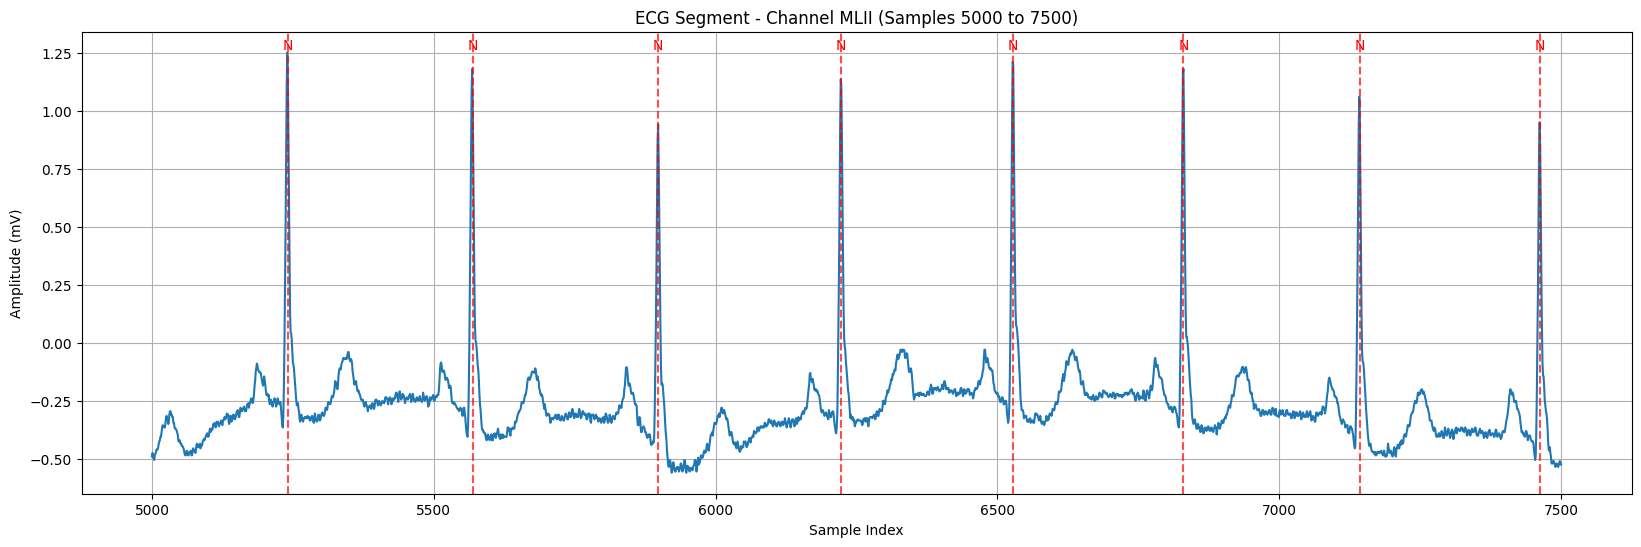

In [36]:
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"

ecg_df, annotations_df, sample_rate = load_ecg_data(
    record_number=101,
    max_duration=30,
    wfdb_root=wfdb_root
)

plot_ecg_segment(
    ecg_df=ecg_df,
    annotations_df=annotations_df,
    channel_name="MLII",
    start_index=5000,
    end_index=7500
)

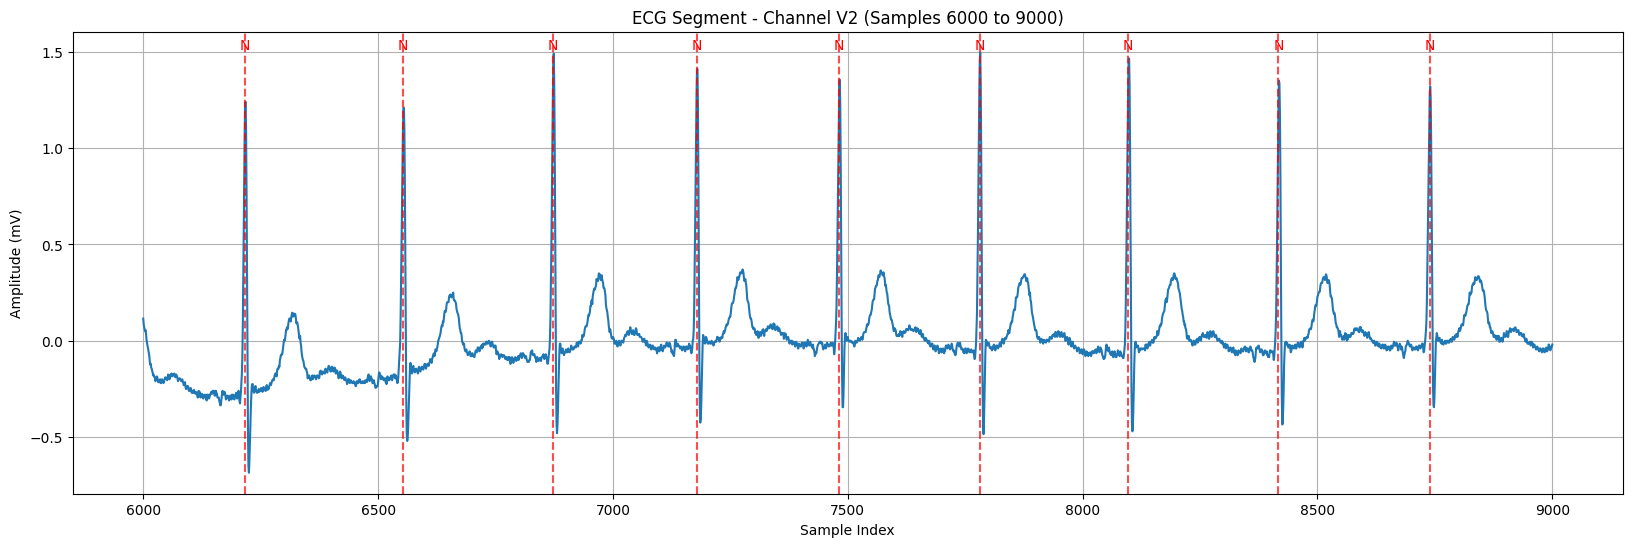

In [37]:
ecg_df_103, annotations_df_103, sample_rate_103 = load_ecg_data(
    record_number=103,
    max_duration=30,
    wfdb_root=wfdb_root
)

plot_ecg_segment(
    ecg_df=ecg_df_103,
    annotations_df=annotations_df_103,
    channel_name="V2",
    start_index=6000,
    end_index=9000
)

In [38]:
#problem-3
import numpy as np
import pandas as pd

def create_segment_table(record_number, max_duration, wfdb_root, segment_duration):
    # 1. Load ECG data using the function from Problem 1
    ecg_df, annotations_df, sample_rate = load_ecg_data(
        record_number,
        max_duration,
        wfdb_root
    )

    # 2. Determine the number of segments
    n_segments = int(np.ceil(max_duration / segment_duration))

    # 3. Split the ECG data into segments
    data_segments = np.array_split(ecg_df.values, n_segments)

    # 4. Split the ECG index into corresponding segments
    index_segments = np.array_split(ecg_df.index.to_numpy(), n_segments)

    # 5. Construct one row per channel per segment
    rows = []

    for segment_index, (data_segment, index_segment) in enumerate(
        zip(data_segments, index_segments)
    ):
        for channel_index, channel_name in enumerate(ecg_df.columns):

            row = {
                "record_number": record_number,
                "segment_index": segment_index,
                "sample_rate": sample_rate,
                "n_samples": len(data_segment),
                "channel_name": channel_name,
                "segment_start_index": index_segment[0],
                "segment": data_segment[:, channel_index]
            }

            rows.append(row)

    # 6. Create and return segment table
    segment_table = pd.DataFrame(rows)

    return segment_table

In [39]:
wfdb_root = "/content/drive/MyDrive/AIHC5020/timeseries/ecg_wfdb"

segment_table_102 = create_segment_table(
    record_number=102,
    max_duration=30,
    wfdb_root=wfdb_root,
    segment_duration=4
)

segment_table_102.head()

,record_number,segment_index,sample_rate,n_samples,channel_name,segment_start_index,segment
0,102,0,360,1350,V5,0,"[-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0...."
1,102,0,360,1350,V2,0,"[0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.0..."
2,102,1,360,1350,V5,1350,"[-0.41, -0.4, -0.385, -0.37, -0.34, -0.305, -0..."
3,102,1,360,1350,V2,1350,"[-2.465, -2.285, -2.11, -1.905, -1.67, -1.425,..."
4,102,2,360,1350,V5,2700,"[-0.225, -0.23, -0.24, -0.245, -0.255, -0.25, ..."


In [40]:
#problem-4
!pip install -q pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.4 MB/s eta 0:00:00


In [42]:
import os
import pydicom
import pandas as pd

def create_dicom_manifest(dicom_root):
    manifest_data = []
    for root, _, files in os.walk(dicom_root):
        for file in files:
            if file.endswith('.dcm'):
                dicom_file_path = os.path.join(root, file)
                try:
                    ds = pydicom.dcmread(dicom_file_path, stop_before_pixels=True)
                    manifest_data.append({
                        'file_path': dicom_file_path,
                        'patient_id': getattr(ds, 'PatientID', 'N/A'),
                        'study_instance_uid': getattr(ds, 'StudyInstanceUID', 'N/A'),
                        'series_instance_uid': getattr(ds, 'SeriesInstanceUID', 'N/A'),
                        'sop_instance_uid': getattr(ds, 'SOPInstanceUID', 'N/A'),
                        'modality': getattr(ds, 'Modality', 'N/A')
                    })
                except Exception as e:
                    # Handle files that might not be valid DICOM or other read errors
                    manifest_data.append({
                        'file_path': dicom_file_path,
                        'patient_id': 'ERROR',
                        'study_instance_uid': 'ERROR',
                        'series_instance_uid': 'ERROR',
                        'sop_instance_uid': 'ERROR',
                        'modality': 'ERROR',
                        'error': str(e)
                    })
    return pd.DataFrame(manifest_data)

dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI"

manifest_df = create_dicom_manifest(dicom_root)

manifest_df.head()

,file_path,patient_id,study_instance_uid,series_instance_uid,sop_instance_uid,modality
0,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...,1.3.6.1.4.1.14519.5.2.1.6279.6001.188744668142...,1.3.6.1.4.1.14519.5.2.1.6279.6001.320659674397...,DX
1,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.618422555692...,1.3.6.1.4.1.14519.5.2.1.6279.6001.188744668142...,1.3.6.1.4.1.14519.5.2.1.6279.6001.224109014755...,DX
2,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.2.276.0.7230010.3.1.3.0.89648.1553284309.77342,1.2.276.0.7230010.3.1.4.0.89648.1553284309.77343,SEG
3,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.2.276.0.7230010.3.1.3.0.89692.1553284316.639961,1.2.276.0.7230010.3.1.4.0.89692.1553284316.639962,SEG
4,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,1.3.6.1.4.1.14519.5.2.1.6279.6001.859626709959...,CT


In [44]:
from pathlib import Path
import pandas as pd
import pydicom

def create_dicom_manifest(root_dir: str):
    root_path = Path(root_dir)
    manifest_rows = []

    for folder in root_path.rglob("*"):

        if not folder.is_dir():
            continue

        dcm_files = list(folder.glob("*.dcm"))

        if len(dcm_files) == 0:
            continue

        try:
            ds = pydicom.dcmread(dcm_files[0])

            manifest_rows.append({
                "patient_id": ds.get("PatientID", "N/A"),
                "study_date": ds.get("StudyDate", "N/A"),
                "modality": ds.get("Modality", "N/A"),
                "study_description": ds.get("StudyDescription", "N/A"),
                "series_description": ds.get("SeriesDescription", "N/A"),
                "n_images": len(dcm_files),
                "study_instance_uid": ds.get("StudyInstanceUID", "N/A"),
                "series_instance_uid": ds.get("SeriesInstanceUID", "N/A"),
                "series_path": str(folder)
            })

        except Exception as e:
            print(f"Error reading {dcm_files[0]}: {e}")

    return pd.DataFrame(manifest_rows)


# Create manifest
dicom_root = "/content/drive/MyDrive/AIHC5020/dicom/tcia/LIDC-IDRI"

manifest_df = create_dicom_manifest(dicom_root)

# Display first five rows
display(manifest_df.head())

# Challenge case: display all CT series
ct_manifest = manifest_df[manifest_df["modality"] == "CT"]

display(ct_manifest)

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
1,LIDC-IDRI-0001,20000101,SR,N/A,Nodule 1 - Annotation Nodule 001 evaluations,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89315.1553284069.532969,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
2,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation 0,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89358.1553284079.860324,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
3,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation Nodule 001,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
4,LIDC-IDRI-0001,20000101,SEG,N/A,Segmentation of Nodule 1 - Annotation MI014_12127,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.2.276.0.7230010.3.1.3.0.89355.1553284075.626419,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
0,LIDC-IDRI-0001,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
10,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
16,LIDC-IDRI-0005,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
46,LIDC-IDRI-0003,20000101,CT,N/A,N/A,140,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
69,LIDC-IDRI-0004,20000101,CT,N/A,N/A,241,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...
77,LIDC-IDRI-0006,20000101,CT,N/A,N/A,133,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


In [45]:
#problem-5
from pathlib import Path
import numpy as np
import pydicom
import matplotlib.pyplot as plt

def visualize_ct_series(manifest_row):
    # 1. Validate that this is a raw CT series
    if manifest_row["modality"] != "CT":
        raise ValueError("The selected manifest row is not a CT series.")

    if manifest_row["n_images"] <= 1:
        raise ValueError("The selected CT series must contain more than one image.")

    # Get all DICOM files from the series folder
    series_path = Path(manifest_row["series_path"])
    dcm_files = list(series_path.glob("*.dcm"))

    # Load all slices
    slices = []
    for file in dcm_files:
        try:
            ds = pydicom.dcmread(file)
            slices.append(ds)
        except Exception as e:
            print(f"Could not read {file}: {e}")

    # Sort slices by InstanceNumber
    slices = sorted(
        slices,
        key=lambda x: int(x.InstanceNumber)
    )

    # 2. Select slices at approximately 20%, 40%, 60%, and 80%
    n_slices = len(slices)

    sample_indices = [
        int(n_slices * 0.2),
        int(n_slices * 0.4),
        int(n_slices * 0.6),
        int(n_slices * 0.8)
    ]

    selected_slices = [slices[i] for i in sample_indices]

    # Create montage
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    for ax, ct_slice in zip(axes, selected_slices):

        ax.imshow(
            ct_slice.pixel_array,
            cmap="gray"
        )

        ax.set_title(
            f"Slice {ct_slice.InstanceNumber}"
        )

        ax.set_axis_off()

    # 3. Overall figure title
    fig.suptitle(
        f"Patient: {manifest_row['patient_id']} | "
        f"Study Date: {manifest_row['study_date']}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [46]:
patient_0002_ct = manifest_df[
    (manifest_df["patient_id"] == "LIDC-IDRI-0002") &
    (manifest_df["modality"] == "CT") &
    (manifest_df["n_images"] > 1)
]

patient_0002_ct

,patient_id,study_date,modality,study_description,series_description,n_images,study_instance_uid,series_instance_uid,series_path
10,LIDC-IDRI-0002,20000101,CT,N/A,N/A,261,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,/content/drive/MyDrive/AIHC5020/dicom/tcia/LID...


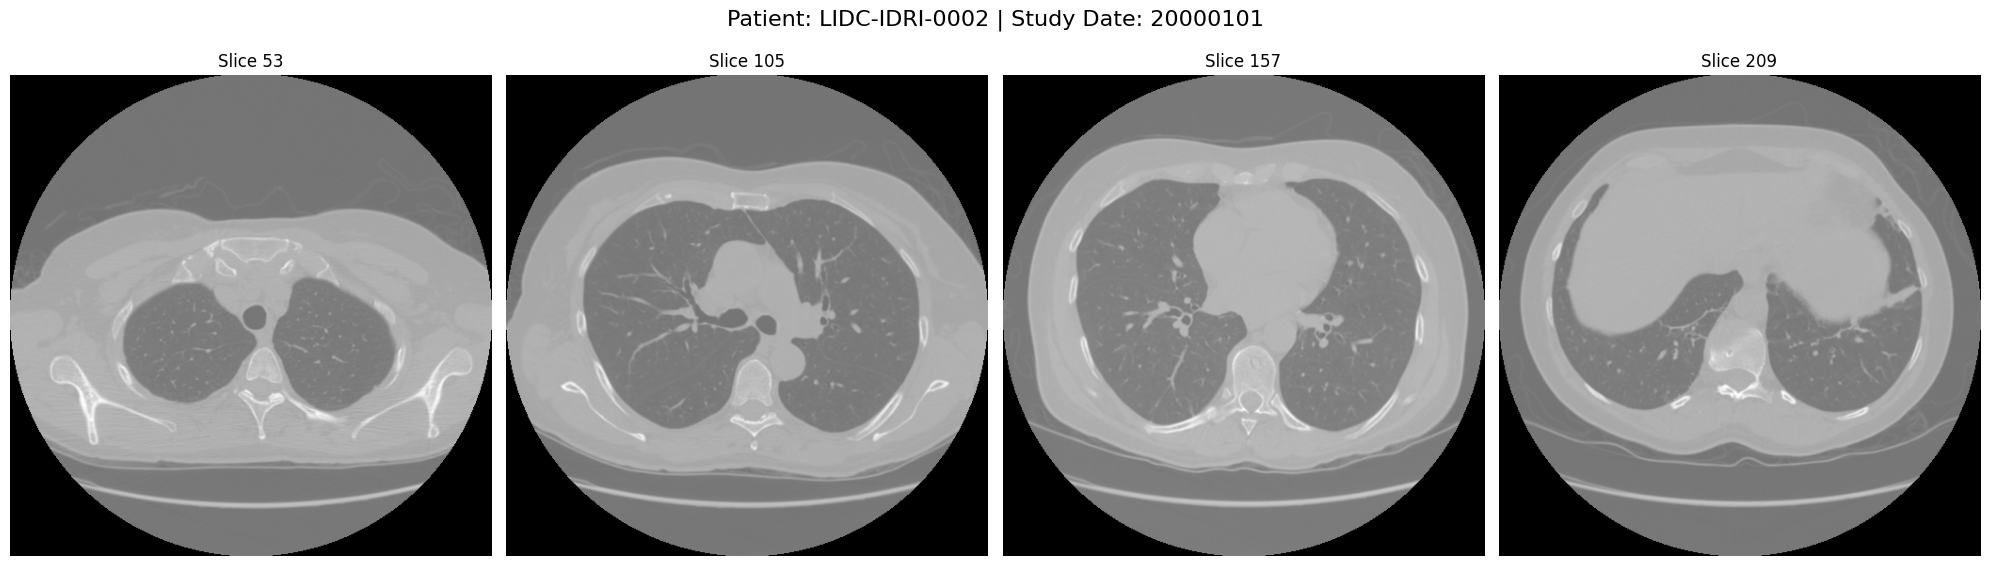

In [47]:
visualize_ct_series(
    patient_0002_ct.iloc[0]
)

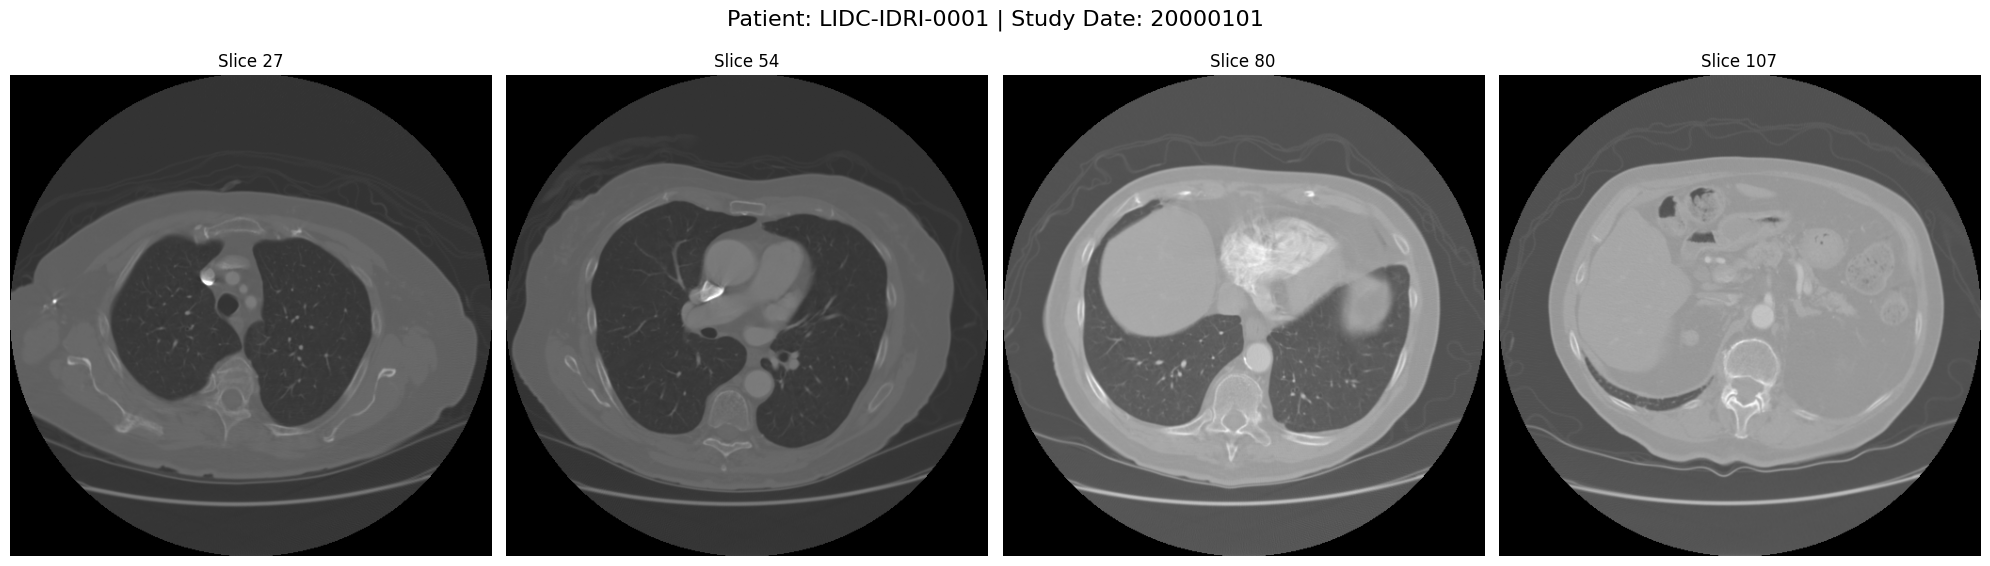

In [48]:
patient_0001_ct = manifest_df[
    (manifest_df["patient_id"] == "LIDC-IDRI-0001") &
    (manifest_df["modality"] == "CT") &
    (manifest_df["n_images"] > 1)
]

visualize_ct_series(
    patient_0001_ct.iloc[0]
)